In [16]:
# Imports
import sys
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Custom Imports
root_dir = Path('.').resolve().parent
src_path = str(root_dir / "src")

if src_path not in sys.path :
    sys.path.append(src_path)

from model_explainability import (test_nodes, explaination_gnn, explainer)
from model_train import (model, data)
from feature_engineering import (predicate_to_id, edge_type)

# Single Test Node

In [2]:
test_node = test_nodes[0]
print("Test Node : ", test_node)

Test Node :  tensor(338)


In [3]:
# Explore Explainations

print(explaination_gnn)
print(explaination_gnn.edge_mask.max())

Explanation(node_mask=[2835, 2835], edge_mask=[20338], prediction=[2835, 5], target=[2835], index=[1], x=[2835, 2835], edge_index=[2, 20338])
tensor(0.1392)


In [4]:
# Find out Top Edges
top_edges = explaination_gnn.edge_mask.topk(10)

# Extract indices from top_edges
important_edge_indices = top_edges.indices


Counter({'author': 3, 'publication': 3, 'isAbout': 2, 'dealtWithIn': 1, 'member': 1})


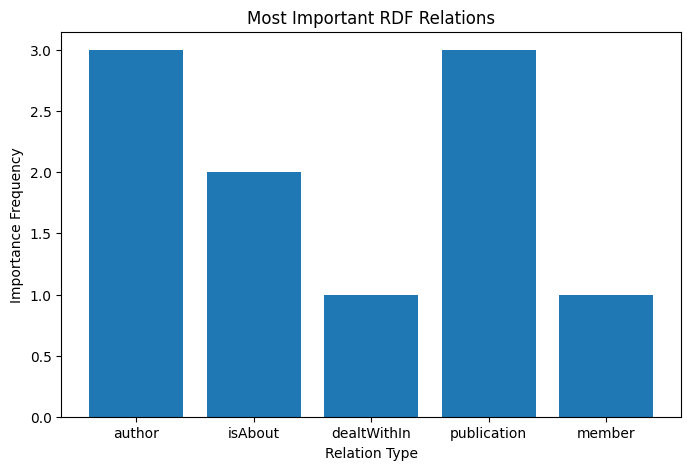

In [5]:
# Important Relation Frequency Plot

important_relations = []
# Create reverse mapping for relations
id_to_relation = {v: k for k, v in predicate_to_id.items()}

for idx in important_edge_indices:

    idx = idx.item()
    rel_id = edge_type[idx].item()
    relation = id_to_relation[rel_id]
    clean_relation = relation.split("#")[-1]
    important_relations.append(clean_relation)

relation_counts = Counter(important_relations)
print(relation_counts)



# Visulisation (Bar Plot)
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(8,5))
plt.bar(relations, counts)
plt.xlabel("Relation Type")
plt.ylabel("Importance Frequency")
plt.title("Most Important RDF Relations")
plt.show()

In [6]:
# Generate Sub Graph
subgraph = explaination_gnn.get_explanation_subgraph()
print(subgraph)

Explanation(node_mask=[309, 2835], edge_mask=[701], prediction=[309, 5], target=[309], index=[1], x=[309, 2835], edge_index=[2, 701])


Counter({'publication': 5, 'author': 5, 'type': 4, 'isAbout': 2, 'member': 1, 'hasProject': 1, 'isWorkedOnBy': 1, 'dealtWithIn': 1})


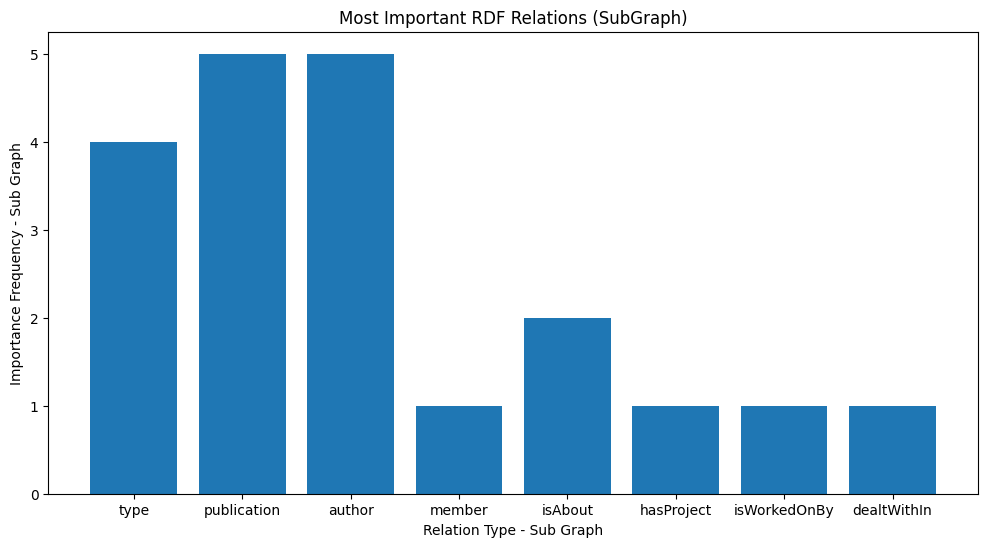

In [7]:
important_edge_indices = subgraph.edge_mask.topk(20).indices

# EXTRACT RELATION NAMES
important_relations = []

for idx in important_edge_indices:

    idx = idx.item()
    rel_id = edge_type[idx].item()
    relation = id_to_relation[rel_id] 
    clean_relation = relation.split("#")[-1]
    important_relations.append(clean_relation)


relation_counts = Counter(important_relations)
print(relation_counts)

# Visulisation
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(12,6))
plt.bar(relations, counts)
plt.xlabel("Relation Type - Sub Graph")
plt.ylabel("Importance Frequency - Sub Graph")
plt.title("Most Important RDF Relations (SubGraph)")
plt.show()

# Multipal Test Nodes

In [ ]:
# test_nodes = labeled_nodes[:5]
# print(test_nodes)

all_relation_lists = []

# Loop throw the test nodes
for node in test_nodes:

    print("Explaining Node:", node)
    print("-------")

    explanation = explainer(

        x=data.x,
        edge_index=data.edge_index,
        index=int(node)
    )

    important_edges = explanation.edge_mask.topk(20).indices

    relations = []

    for idx in important_edges:

        idx = idx.item()
        rel_id = edge_type[idx].item()
        relation = id_to_relation[rel_id]
        clean_relation = relation.split("#")[-1]
        relations.append(clean_relation)
    # print(relations)
    all_relation_lists.append(relations)


Counter({'isAbout': 27, 'publication': 24, 'type': 18, 'author': 10, 'projectInfo': 6, 'carriedOutBy': 6, 'isWorkedOnBy': 5, 'dealtWithIn': 3, 'publishes': 1})


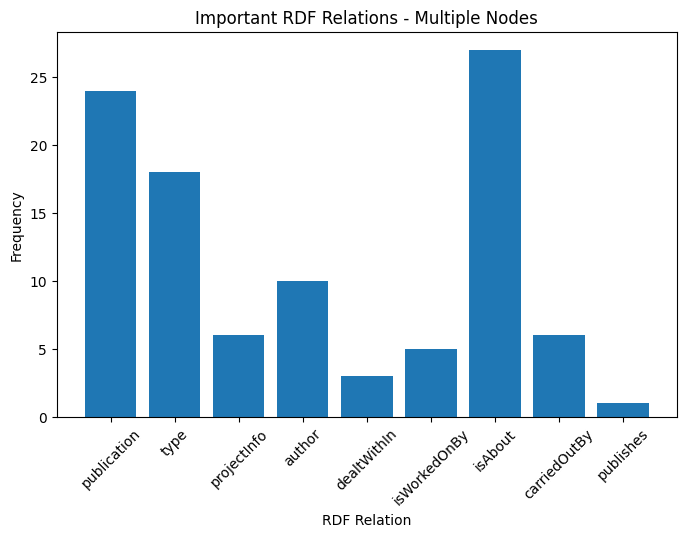

In [ ]:
# Combine All Relations
all_relations = []

for relation_list in all_relation_lists:
    all_relations.extend(relation_list)

relation_counter = Counter(all_relations)
print(relation_counter)


# Visulisation
relations = list(relation_counter.keys())
counts = list(relation_counter.values())

plt.figure(figsize=(8,5))
plt.bar(relations, counts)
plt.xlabel("RDF Relation")
plt.ylabel("Frequency")
plt.title("Important RDF Relations - Multiple Nodes")
plt.xticks(rotation=45)
plt.show()

# Faithfulness Check

If we remove those important edges, does prediction change ?

Tasks :-

1. Get original prediction

2. Remove important edges

3. Run model again

4. Compare prediction confidence

In [20]:
# RESET EXPLAIN MODE
model.conv1.explain = False
model.conv2.explain = False

# GET ORIGINAL PREDICTION
model.eval()

with torch.no_grad():

    original_out = model(
        data.x,
        data.edge_index,
        data.edge_type
    )

original_prediction = original_out[test_node]
#print(original_prediction)


# GET ORIGINAL CONFIDENCE
original_probs = F.softmax(
    original_prediction,
    dim=0
)
print(original_probs)


# GET Top 50 IMPORTANT EDGES
important_edges = explanation.edge_mask.topk(50).indices
#print(important_edges)

# CREATE EDGE MASK
num_edges = data.edge_index.shape[1]
keep_mask = torch.ones(
    num_edges,
    dtype=torch.bool
)
keep_mask[important_edges] = False

# CREATE MODIFIED GRAPH
new_edge_index = data.edge_index[:, keep_mask]
new_edge_type = data.edge_type[keep_mask]

with torch.no_grad():

    modified_out = model(
        data.x,
        new_edge_index,
        new_edge_type
    )
modified_prediction = modified_out[test_node]
modified_probs = F.softmax(
    modified_prediction,
    dim=0
)
print(modified_probs)

tensor([0.2143, 0.1839, 0.2015, 0.2031, 0.1971])
tensor([0.2143, 0.1839, 0.2015, 0.2031, 0.1971])


# WRONG PREDICTION ANALYSIS

In [ ]:
# Find Wrong Predictions
model.eval()

with torch.no_grad():

    out = gcn_model(
        data.x,
        data.edge_index
    )

pred = out.argmax(dim=1)



# Identify Wrong Predictions
wrong_predictions = (
    pred[data.test_mask] != data.y[data.test_mask]
).nonzero(as_tuple=True)[0]

print("Total Wrong Predictions:", len(wrong_predictions))



# GET ACTUAL NODE IDS
test_nodes = data.test_mask.nonzero(
    as_tuple=True
)[0]

wrong_node_ids = test_nodes[wrong_predictions]
# print(wrong_node_ids[:10])


# Get True Vs Predicted Class
for node in wrong_node_ids[:10]:

    true_label = data.y[node].item()
    predicted_label = pred[node].item()

    # print("Node:", node.item())
    # print("True Label:", true_label)
    # print("Predicted:", predicted_label)
    # print()

Total Wrong Predictions: 29


### # GENERATE EXPLANATION FOR WRONG NODE

In [ ]:
wrong_node = int(wrong_node_ids[0])

# Generate Explaination
wrong_explanation = explainer(

    x=data.x,
    edge_index=data.edge_index,
    index=wrong_node
)


# CHECK IMPORTANT RELATIONS

important_edges = (
    wrong_explanation.edge_mask.topk(20).indices
)

for idx in important_edges:

    rel_id = edge_type[idx].item()
    # print( id_to_relation[rel_id] )

# Check Confidence of Wrong Predictions
probabilities = F.softmax(
    out[wrong_node],
    dim=0
)

print(probabilities)

tensor([0.2009, 0.1999, 0.2011, 0.1988, 0.1994])


# Compare Correct vs Wrong Prediction Explanations

In [ ]:
# GET ONE CORRECT NODE
correct_mask = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
)

correct_node_ids = test_nodes[correct_mask]
#print(correct_node_ids[:10])

# PICK ONE CORRECT NODE
correct_node = int(correct_node_ids[0])
print("Correct Node :- ", correct_node)


# Generate Explaination
correct_explaination = explainer(
    x = data.x,
    edge_index = data.edge_index,
    index = correct_node
)


# Generate SubGraph
correct_subGraph = (
    correct_explaination.get_explanation_subgraph()
)

print("CORRECT NODE EXPLAINATION - ", correct_subGraph)

Correct Node :-  190
CORRECT NODE EXPLAINATION -  Explanation(node_mask=[4, 2835], edge_mask=[6], prediction=[4, 5], target=[4], index=[1], x=[4, 2835], edge_index=[2, 6])


In [ ]:
print("WRONG NODE EXPLAINATION - ", wrong_explanation)

WRONG NODE EXPLAINATION -  Explanation(node_mask=[2835, 2835], edge_mask=[20338], prediction=[2835, 5], target=[2835], index=[1], x=[2835, 2835], edge_index=[2, 20338])


In [ ]:
# COMPARE EDGE IMPORTANCE DISTRIBUTION
print( "CORRECT EXPLAINATION -- EDGE IMPORTANCE", correct_explaination.edge_mask.topk(20).values )
print( "WRONG EXPLAINATION -- EDGE IMPORTANCE",wrong_explanation.edge_mask.topk(20).values )

CORRECT EXPLAINATION -- EDGE IMPORTANCE tensor([0.9296, 0.0735, 0.0735, 0.0735, 0.0734, 0.0720, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])
WRONG EXPLAINATION -- EDGE IMPORTANCE tensor([0.1205, 0.1200, 0.1199, 0.1198, 0.1194, 0.1193, 0.1190, 0.1190, 0.1190,
        0.1189, 0.1188, 0.1188, 0.1188, 0.1187, 0.1187, 0.1187, 0.1186, 0.1186,
        0.1185, 0.1185])


In [24]:
# =====================================================================
# SURROGATE GCN MODEL FAITHFULNESS CHECK (FIXED EXPLAIN STATE)
# =====================================================================
import torch
import torch.nn.functional as F
from model_explainability import gcn_model # Import the actual model used for GNNExplainer

# 1. CRUCIAL FIX: Explicitly deactivate internal explain flags on surrogate layers
if hasattr(gcn_model, 'con1'):
    gcn_model.con1.explain = False
if hasattr(gcn_model, 'conv2'):
    gcn_model.conv2.explain = False

# Put the model in evaluation mode
gcn_model.eval()

# Select the target test node 
target_test_node = test_node

# ---------------------------------------------------------------------
# STEP 1: Get Original Prediction from the Surrogate GCN Model
# ---------------------------------------------------------------------
with torch.no_grad():
    original_out = gcn_model(data.x, data.edge_index)
    
original_probs = F.softmax(original_out[target_test_node], dim=0)
orig_pred_class = torch.argmax(original_probs).item()
orig_confidence = original_probs[orig_pred_class].item()

print("--- Original Surrogate GCN Model State ---")
print(f"Target Test Node: {target_test_node.item() if isinstance(target_test_node, torch.Tensor) else target_test_node}")
print(f"Predicted Class : {orig_pred_class}")
print(f"Class Confidence: {orig_confidence:.4f}\n")

# ---------------------------------------------------------------------
# STEP 2: Extract Top 50 Important Edges from your existing GNN Explanation
# ---------------------------------------------------------------------
important_edges = explaination_gnn.edge_mask.topk(50).indices

# ---------------------------------------------------------------------
# STEP 3: Create Perturbed Graph (Remove Important Edges)
# ---------------------------------------------------------------------
num_edges = data.edge_index.shape[1]
keep_mask = torch.ones(num_edges, dtype=torch.bool)
keep_mask[important_edges] = False
new_edge_index = data.edge_index[:, keep_mask]

# ---------------------------------------------------------------------
# STEP 4: Evaluate against the exact same Surrogate GCN Model
# ---------------------------------------------------------------------
with torch.no_grad():
    modified_out = gcn_model(data.x, new_edge_index)
    
modified_probs = F.softmax(modified_out[target_test_node], dim=0)
new_confidence = modified_probs[orig_pred_class].item()
new_pred_class = torch.argmax(modified_probs).item()

# ---------------------------------------------------------------------
# STEP 5: Compute Faithfulness Metrics
# ---------------------------------------------------------------------
confidence_drop = orig_confidence - new_confidence
label_flipped = orig_pred_class != new_pred_class

print("--- Perturbed Surrogate GCN State (Top 50 Edges Dropped) ---")
print(f"New Predicted Class: {new_pred_class}")
print(f"Confidence for Original Class: {new_confidence:.4f}")
print("-" * 65)
print(f"FAITHFULNESS METRICS (SURROGATE GCN EVALUATION):")
# Using a raw string (r"...") fixes any potential invalid escape sequence bugs
print(fr" - Confidence Drop ($\Delta$ Conf): {confidence_drop:.4f} ({confidence_drop*100:.1f}%)")
print(f" - Prediction Label Flipped?    : {label_flipped} (Status: [{'FLIPPED' if label_flipped else 'STABLE'}])")

--- Original Surrogate GCN Model State ---
Target Test Node: 338
Predicted Class : 4
Class Confidence: 0.2048

--- Perturbed Surrogate GCN State (Top 50 Edges Dropped) ---
New Predicted Class: 4
Confidence for Original Class: 0.2051
-----------------------------------------------------------------
FAITHFULNESS METRICS (SURROGATE GCN EVALUATION):
 - Confidence Drop ($\Delta$ Conf): -0.0003 (-0.0%)
 - Prediction Label Flipped?    : False (Status: [STABLE])
